In [1]:
#!/usr/bin/env python3
"""
EDA Panel Completo — Integración Cross-Dataset (>=20 visualizaciones)
=====================================================================
Panel Big Data >250 GB: S5P + S2 + ERA5 + MODIS + DAGMA
Cada visualización cruza al menos 2 datasets.
"""

import json, warnings, gc
from pathlib import Path
from collections import defaultdict, Counter
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats
import rasterio
import h5py

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
warnings.filterwarnings("ignore")

# ── Rutas (notebook en notebooks/eda/ → subir 2 niveles al ROOT) ──────────────
ROOT         = Path().resolve().parent.parent
S5P_L3_DIR   = ROOT / "data" / "sentinel5p" / "l3"
ERA5_DIR     = ROOT / "data" / "era5"
DAGMA_DIR    = ROOT / "data" / "dagma" / "raw"
S2_MANIFEST  = ROOT / "data" / "manifests" / "manifest_sentinel2.json"
MOD_MANIFEST = ROOT / "data" / "manifests" / "manifest_modis_maiac.json"
ERA5_MANIFEST = ROOT / "data" / "manifests" / "manifest_era5.json"
OUT_DIR      = ROOT / "outputs" / "eda" / "panel"
OUT_DIR.mkdir(parents=True, exist_ok=True)
DPI = 150

colors_ds = {"S5P":"#E53935","S2":"#1E88E5","ERA5":"#43A047","MODIS":"#FFC107","DAGMA":"#8E24AA"}
cols_pie  = ["#E53935","#1E88E5","#43A047","#FFC107","#8E24AA"]

print(f"ROOT    : {ROOT}")
print(f"OUT_DIR : {OUT_DIR}")


ROOT    : /home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality
OUT_DIR : /home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/panel


## Fase 1 · Cobertura temporal por dataset

In [2]:
print("[Fase 1/6] Cargando fechas de cada dataset...")

# S5P
s5p_dates = set()
for yd in sorted(S5P_L3_DIR.iterdir()):
    if not yd.is_dir(): continue
    for md in sorted(yd.iterdir()):
        if not md.is_dir(): continue
        for dd in sorted(md.iterdir()):
            if not dd.is_dir(): continue
            try:
                s5p_dates.add(pd.Timestamp(int(yd.name), int(md.name), int(dd.name)).date())
            except:
                pass

# S2
s2_manifest = json.loads(S2_MANIFEST.read_text())
s2_dates = set()
for e in s2_manifest["archivos"]:
    sid = e["scene_id"]; p = sid.split("_")
    if len(p) >= 3 and len(p[2]) == 8:
        s2_dates.add(pd.Timestamp(int(p[2][:4]), int(p[2][4:6]), int(p[2][6:8])).date())

# ERA5
era5_manifest = json.loads(ERA5_MANIFEST.read_text())
era5_dates = set()
for e in era5_manifest["archivos"]:
    for d in range(1, 32):
        try:
            era5_dates.add(pd.Timestamp(e["year"], e["month"], d).date())
        except:
            pass

# MODIS
mod_manifest = json.loads(MOD_MANIFEST.read_text())
mod_dates = set()
for g in mod_manifest["granules"]:
    parts = g["name"].split(".")
    j = parts[1]; y, doy = int(j[1:5]), int(j[5:8])
    mod_dates.add((pd.Timestamp(y, 1, 1) + pd.Timedelta(days=doy - 1)).date())

# DAGMA
dagma_dates = set()
for f in sorted(DAGMA_DIR.glob("g4t8_*.csv")):
    try:
        df_tmp = pd.read_csv(f, usecols=["med_fecha_inicio"], nrows=5000, encoding="utf-8")
        dts = pd.to_datetime(df_tmp["med_fecha_inicio"], errors="coerce").dt.date.dropna().unique()
        dagma_dates.update(dts)
    except:
        pass

all_dates = sorted(s5p_dates | s2_dates | era5_dates | mod_dates | dagma_dates)
start, end = min(all_dates), max(all_dates)
datasets = {"S5P": s5p_dates, "S2": s2_dates, "ERA5": era5_dates, "MODIS": mod_dates, "DAGMA": dagma_dates}

print(f"  Rango: {start} → {end}  ({len(all_dates)} días)")
for k, v in datasets.items():
    print(f"  {k:6s}: {len(v)} días")


[Fase 1/6] Cargando fechas de cada dataset...
  Rango: 2020-01-01 → 2025-12-31  (2192 días)
  S5P   : 1827 días
  S2    : 190 días
  ERA5  : 2192 días
  MODIS : 1822 días
  DAGMA : 264 días


## Fig 1 · Cobertura temporal por dataset

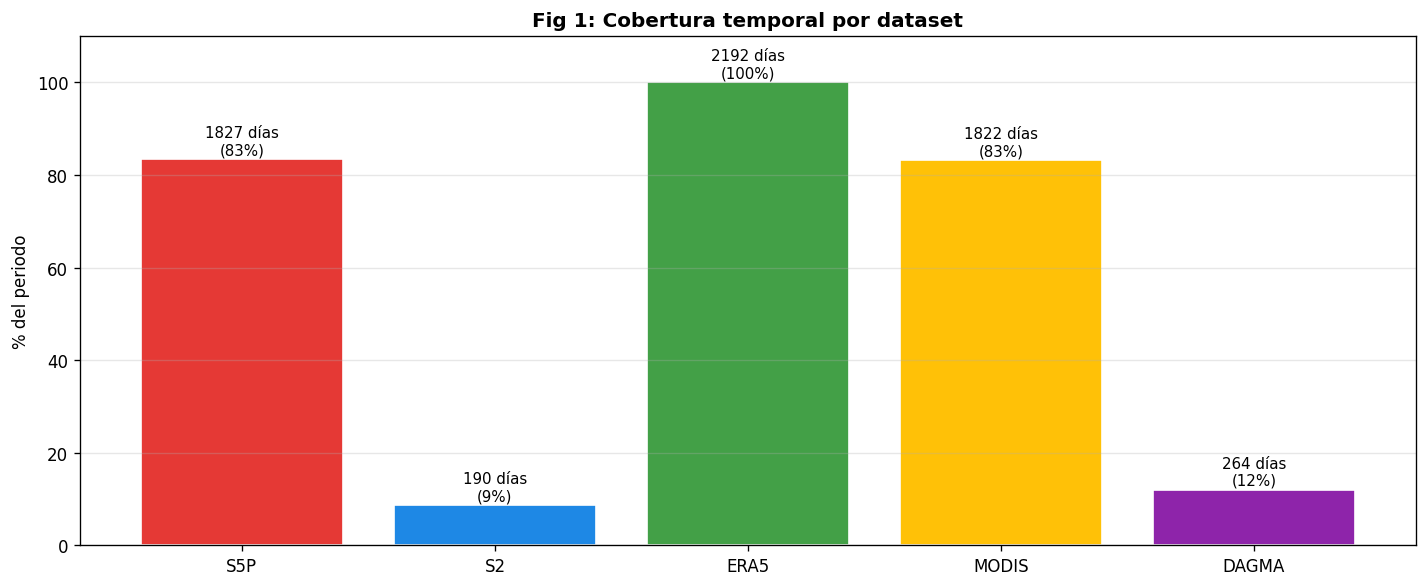

In [3]:
fig, ax = plt.subplots(figsize=(12, 5))

for i, (ds_name, ds_set) in enumerate(datasets.items()):
    pct = len(ds_set) / len(all_dates) * 100
    ax.bar(i, pct, color=colors_ds[ds_name], edgecolor="white")
    ax.text(i, pct + 1, f"{len(ds_set)} días\n({pct:.0f}%)", ha="center", fontsize=9)

ax.set_xticks(range(5))
ax.set_xticklabels(datasets.keys())
ax.set_ylabel("% del periodo")
ax.set_ylim(0, 110)
ax.set_title("Fig 1: Cobertura temporal por dataset", fontweight="bold")
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "01_cobertura_datasets.png", dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()


## Fig 2 · Disponibilidad mensual por dataset (heatmap)

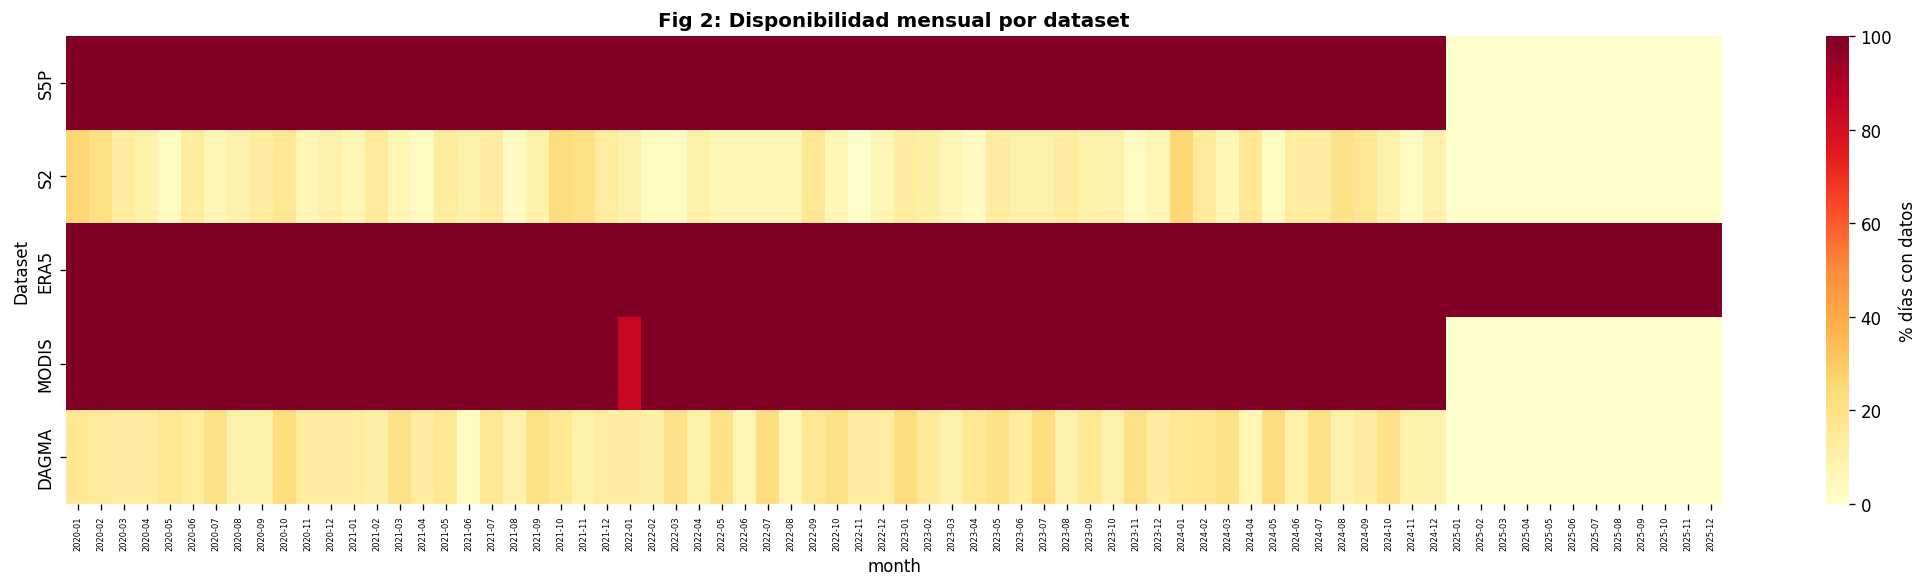

In [4]:
overlap_daily = []
for d in all_dates:
    overlap_daily.append([d in ds for ds in datasets.values()])

overlap_df = pd.DataFrame(overlap_daily, columns=list(datasets.keys()))
overlap_df["date"]  = all_dates
overlap_df["month"] = pd.to_datetime(all_dates).to_period("M")
overlap_monthly = overlap_df.groupby("month")[list(datasets.keys())].mean() * 100

fig, ax = plt.subplots(figsize=(18, 5))
sns.heatmap(overlap_monthly.T, cmap="YlOrRd", ax=ax,
            cbar_kws={"label": "% días con datos"}, vmin=0, vmax=100)
ax.set_title("Fig 2: Disponibilidad mensual por dataset", fontweight="bold")
ax.set_ylabel("Dataset")
ax.set_xticklabels([str(m) for m in overlap_monthly.index], rotation=90, fontsize=5)

plt.tight_layout()
plt.savefig(OUT_DIR / "02_heatmap_disponibilidad.png", dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()


## Fase 2 · Extracción serie temporal NO₂ desde S5P

In [5]:
print("[Fase 2/6] Series NO2 desde S5P...")
no2_dates = []; no2_means = []
processed = 0

for yd in sorted(S5P_L3_DIR.iterdir()):
    if not yd.is_dir(): continue
    for md in sorted(yd.iterdir()):
        if not md.is_dir(): continue
        for dd in sorted(md.iterdir()):
            if not dd.is_dir(): continue
            no2f = dd / "NO2.tif"; clf = dd / "CLOUD.tif"
            if not no2f.exists() or not clf.exists(): continue
            try:
                with rasterio.open(clf) as s:
                    cl = s.read(1).astype(np.float32)
                with rasterio.open(no2f) as s:
                    no2 = s.read(1).astype(np.float32)
                mask = (cl <= 0.3) & (no2 > 0)
                if mask.sum() > 100:
                    no2_dates.append(pd.Timestamp(int(yd.name), int(md.name), int(dd.name)))
                    no2_means.append(float(np.nanmean(no2[mask]) * 1e6))
            except:
                pass
            processed += 1
            if processed % 3000 == 0:
                print(f"  {processed} fechas procesadas...")

no2_ts = pd.DataFrame({"date": no2_dates, "no2": no2_means}).sort_values("date")
no2_ts["date"] = pd.to_datetime(no2_ts["date"])
print(f"  NO2 S5P: {len(no2_ts)} días con datos")


[Fase 2/6] Series NO2 desde S5P...
  NO2 S5P: 1533 días con datos


## Fase 3 · ERA5 — BLH y Temperatura

In [6]:
print("[Fase 3/6] ERA5 BLH y Temperatura...")
era5_blh = {}; era5_temp = {}

for f in sorted(ERA5_DIR.rglob("*.nc")):
    try:
        with h5py.File(f, "r") as h5:
            parts = Path(f).stem.split("_")
            y, m  = int(parts[2]), int(parts[3])
            var   = parts[4]
            if var == "blh" and "blh" in h5:
                blh_data = h5["blh"][:].flatten()
                times    = h5["valid_time"][:].flatten()[:len(blh_data)]
                for t, v in zip(times, blh_data):
                    dt = pd.Timestamp.utcfromtimestamp(t).date()
                    era5_blh[dt] = float(np.nanmean(v))
            elif var == "t2m" and "t2m" in h5:
                t_data = h5["t2m"][:].flatten() - 273.15
                times  = h5["valid_time"][:].flatten()[:len(t_data)]
                for t, v in zip(times, t_data):
                    dt = pd.Timestamp.utcfromtimestamp(t).date()
                    era5_temp[dt] = float(np.nanmean(v))
    except:
        pass

print(f"  BLH: {len(era5_blh)} días, Temp: {len(era5_temp)} días")


[Fase 3/6] ERA5 BLH y Temperatura...
  BLH: 2192 días, Temp: 2192 días


## Fase 4 · NDVI desde Sentinel-2

In [7]:
print("[Fase 4/6] NDVI desde Sentinel-2...")
s2_ndvi = {}

for e in s2_manifest["archivos"][:50]:   # Muestra 50 escenas
    band = e["banda"]
    if band not in ["B04", "B08"]: continue
    sid = e["scene_id"]; p = sid.split("_")
    if len(p) < 3: continue
    dt = pd.Timestamp(int(p[2][:4]), int(p[2][4:6]), int(p[2][6:8]))
    try:
        with rasterio.open(Path(e["file"])) as src:
            data = src.read(1, out_shape=(64, 64)).astype(np.float32) / 10000
        if band == "B04":
            s2_ndvi.setdefault(dt.date(), {})["red"] = data
        elif band == "B08":
            s2_ndvi.setdefault(dt.date(), {})["nir"] = data
    except:
        pass

s2_ndvi_vals = {}
for dt, bands in s2_ndvi.items():
    if "red" in bands and "nir" in bands:
        ndvii = (bands["nir"] - bands["red"]) / (bands["nir"] + bands["red"] + 1e-10)
        s2_ndvi_vals[dt] = float(np.nanmedian(ndvii[(ndvii > -1) & (ndvii < 1)]))

print(f"  NDVI: {len(s2_ndvi_vals)} escenas procesadas")


[Fase 4/6] NDVI desde Sentinel-2...
  NDVI: 2 escenas procesadas


## Fase 5+6 · MODIS metadata + DAGMA NO₂

In [8]:
print("[Fase 5/6] MODIS metadata...")
mod_dates_list = sorted(mod_dates)
mod_monthly = defaultdict(int)
for d in mod_dates_list:
    mod_monthly[(d.year, d.month)] += 1
print(f"  MODIS: {len(mod_dates_list)} días, {len(mod_monthly)} meses")

print("[Fase 6/6] DAGMA NO2...")
dagma_no2 = []
for f in sorted(DAGMA_DIR.glob("g4t8_*.csv")):
    for c in pd.read_csv(f, usecols=["msfl_code", "med_concentracion_estandar", "med_fecha_inicio"],
                          chunksize=50_000, encoding="utf-8", on_bad_lines="skip"):
        c = c[c["msfl_code"] == "NO2"]
        c["fecha"] = pd.to_datetime(c["med_fecha_inicio"], errors="coerce")
        c["valor"] = pd.to_numeric(c["med_concentracion_estandar"], errors="coerce")
        c = c.dropna(subset=["fecha", "valor"])
        for _, r in c.iterrows():
            dagma_no2.append({"date": r["fecha"].date(), "no2_dagma": r["valor"]})

if dagma_no2:
    dagma_no2_df = pd.DataFrame(dagma_no2).groupby("date")["no2_dagma"].mean().reset_index()
    dagma_no2_df["date"] = pd.to_datetime(dagma_no2_df["date"])
else:
    dagma_no2_df = pd.DataFrame()

print(f"  DAGMA NO2: {len(dagma_no2_df)} días")


[Fase 5/6] MODIS metadata...
  MODIS: 1822 días, 60 meses
[Fase 6/6] DAGMA NO2...
  DAGMA NO2: 948 días


## Fig 3 · NO₂ S5P vs Altura de Capa Límite (ERA5 BLH)

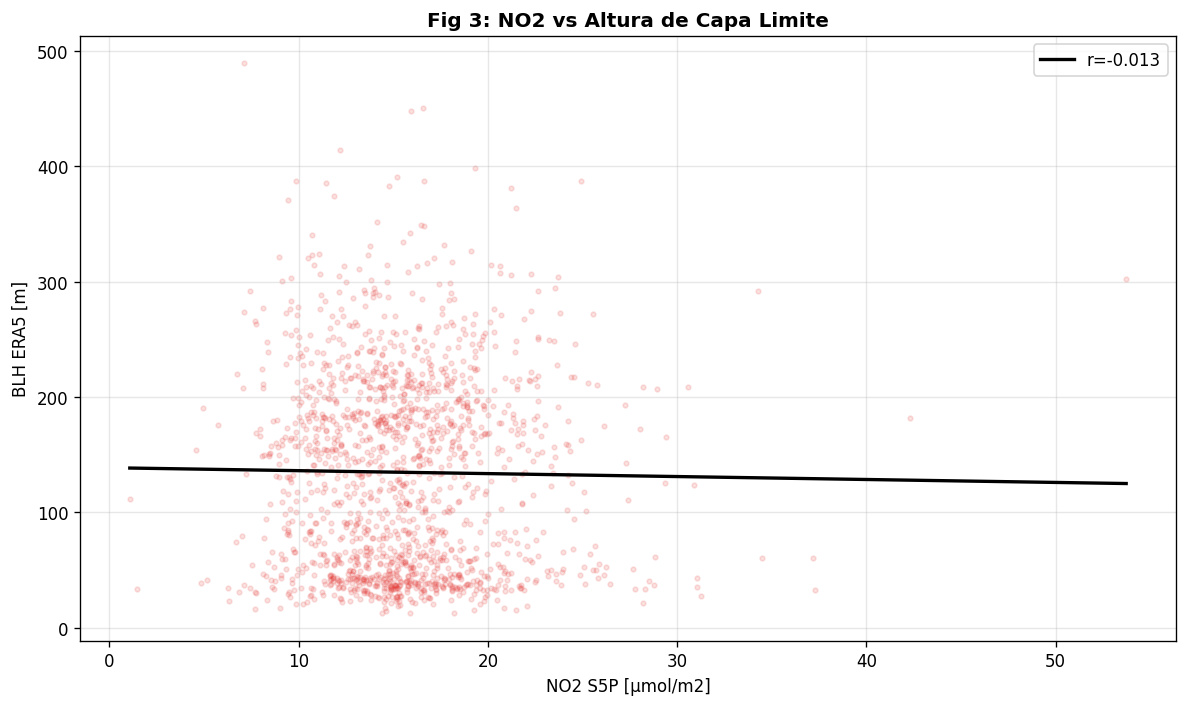

In [9]:
common_dates = sorted(set(d.date() for d in no2_ts["date"]) & set(era5_blh.keys()))

if len(common_dates) > 30:
    x = [no2_ts[no2_ts["date"] == pd.Timestamp(d)]["no2"].values[0]
         for d in common_dates
         if len(no2_ts[no2_ts["date"] == pd.Timestamp(d)]) > 0]
    y = [era5_blh[d] for d in common_dates[:len(x)]]
    x, y = x[:min(len(x), len(y))], y[:min(len(x), len(y))]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(x, y, alpha=0.15, s=8, c="#E53935")
    sl, ic, r, p, _ = stats.linregress(x, y)
    xf = np.linspace(min(x), max(x), 100)
    ax.plot(xf, sl * xf + ic, "k-", lw=2, label=f"r={r:.3f}")
    ax.set_xlabel("NO2 S5P [µmol/m2]")
    ax.set_ylabel("BLH ERA5 [m]")
    ax.legend()
    ax.set_title("Fig 3: NO2 vs Altura de Capa Limite", fontweight="bold")
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUT_DIR / "03_no2_vs_blh.png", dpi=DPI, bbox_inches="tight", facecolor="white")
    plt.show()
else:
    print(f"  Datos insuficientes: {len(common_dates)} fechas comunes (mínimo 30)")


## Fig 4 · O₃ S5P vs Temperatura ERA5 (efecto fotoquímico)

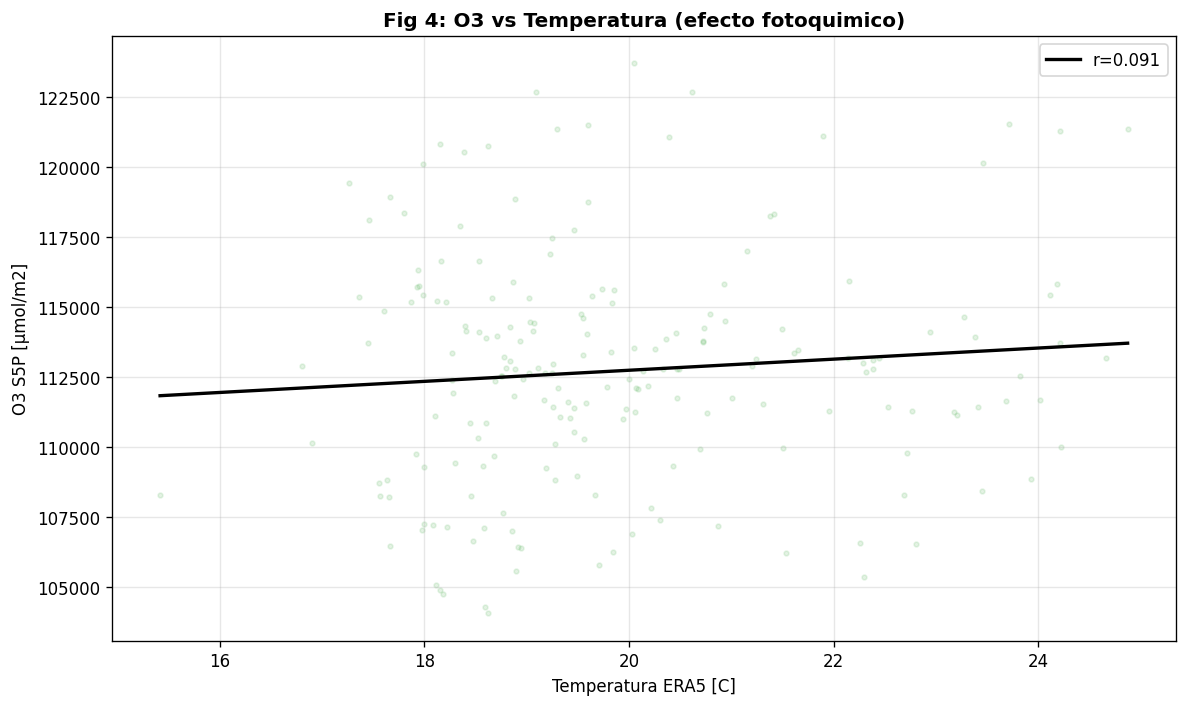

In [10]:
common_t = sorted(set(d.date() for d in no2_ts["date"]) & set(era5_temp.keys()))

if len(common_t) > 30:
    o3_means = []
    for yd, md, dd in [(d.year, d.month, d.day) for d in common_t[:200]]:
        o3f = S5P_L3_DIR / str(yd) / f"{md:02d}" / f"{dd:02d}" / "O3.tif"
        if o3f.exists():
            try:
                with rasterio.open(o3f) as s:
                    o3 = s.read(1).astype(np.float32)
                if (o3 > 0).sum() > 100:
                    o3_means.append((pd.Timestamp(yd, md, dd), float(np.nanmean(o3[o3 > 0]) * 1e6)))
            except:
                pass

    if o3_means:
        temps = [era5_temp[d.date()] for d, _ in o3_means if d.date() in era5_temp]
        o3s   = [v for d, v in o3_means if d.date() in era5_temp]

        fig, ax = plt.subplots(figsize=(10, 6))
        ax.scatter(temps, o3s, alpha=0.15, s=8, c="#4CAF50")
        sl, ic, r, p, _ = stats.linregress(temps, o3s)
        xf = np.linspace(min(temps), max(temps), 100)
        ax.plot(xf, sl * xf + ic, "k-", lw=2, label=f"r={r:.3f}")
        ax.set_xlabel("Temperatura ERA5 [C]")
        ax.set_ylabel("O3 S5P [µmol/m2]")
        ax.legend()
        ax.set_title("Fig 4: O3 vs Temperatura (efecto fotoquimico)", fontweight="bold")
        ax.grid(alpha=0.3)

        plt.tight_layout()
        plt.savefig(OUT_DIR / "04_o3_vs_temperatura.png", dpi=DPI, bbox_inches="tight", facecolor="white")
        plt.show()
    else:
        print("  No se encontraron archivos O3.tif válidos.")
else:
    print(f"  Datos insuficientes: {len(common_t)} fechas comunes (mínimo 30)")


## Fig 5 · NDVI (S2) vs NO₂ (S5P)

In [11]:
common_n = sorted(set(s2_ndvi_vals.keys()) & set(d.date() for d in no2_ts["date"]))

if len(common_n) > 10:
    n_x = [s2_ndvi_vals[d] for d in common_n]
    n_y = []
    for d in common_n:
        vals = no2_ts[no2_ts["date"] == pd.Timestamp(d)]["no2"].values
        n_y.append(vals[0] if len(vals) > 0 else np.nan)

    valid = ~np.isnan(n_y)
    n_x, n_y = np.array(n_x)[valid], np.array(n_y)[valid]

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.scatter(n_x, n_y, alpha=0.5, s=30, c="#2E7D32", edgecolors="white")
    sl, ic, r, p, _ = stats.linregress(n_x, n_y)
    xf = np.linspace(min(n_x), max(n_x), 100)
    ax.plot(xf, sl * xf + ic, "k-", lw=2, label=f"r={r:.3f}")
    ax.set_xlabel("NDVI mediano")
    ax.set_ylabel("NO2 S5P [µmol/m2]")
    ax.legend()
    ax.set_title("Fig 5: NDVI (S2) vs NO2 (S5P) — mas vegetacion = menos contaminacion?", fontweight="bold")
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(OUT_DIR / "05_ndvi_vs_no2.png", dpi=DPI, bbox_inches="tight", facecolor="white")
    plt.show()
else:
    print(f"  Datos insuficientes: {len(common_n)} fechas comunes (mínimo 10)")


  Datos insuficientes: 2 fechas comunes (mínimo 10)


## Fig 6 · NO₂ mensual — S5P vs DAGMA ground truth

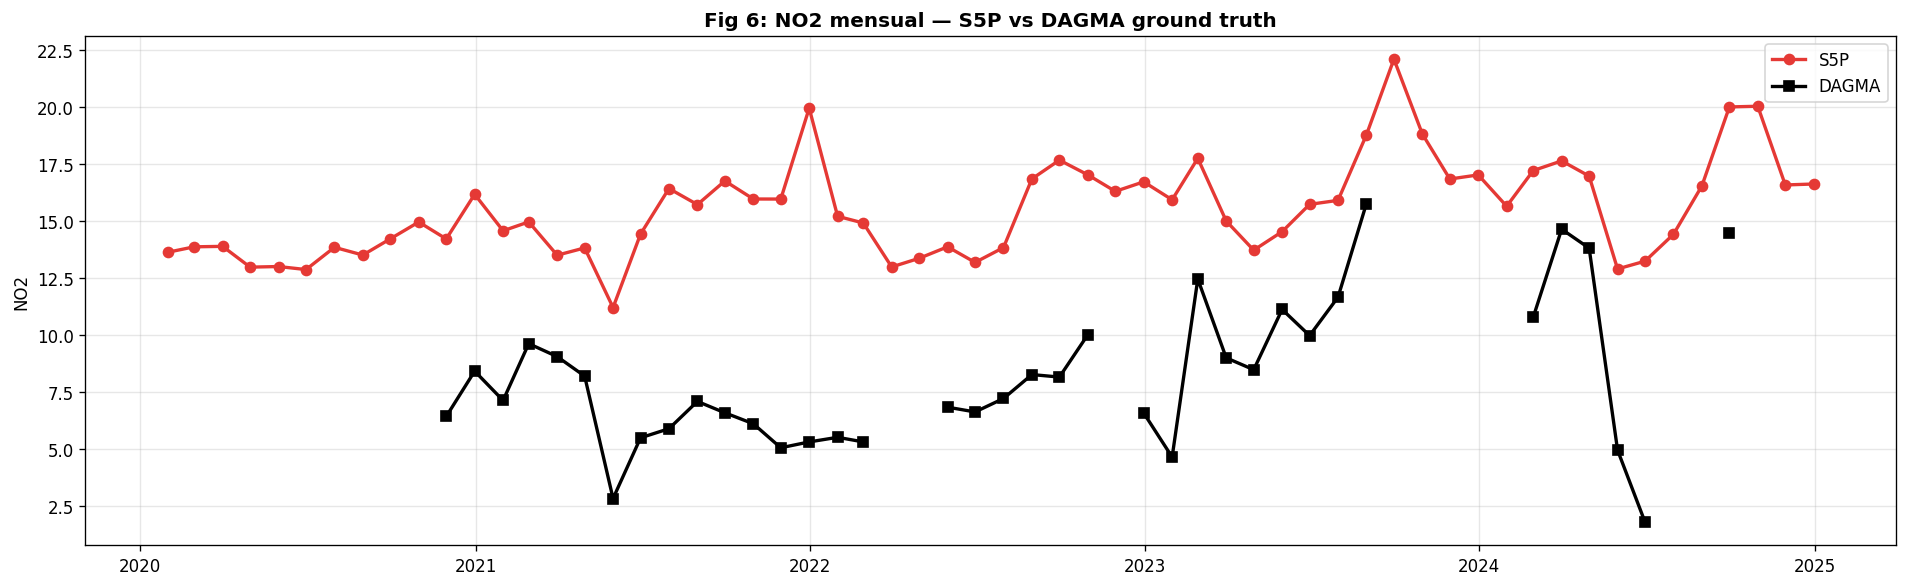

In [12]:
if len(dagma_no2_df) > 10 and len(no2_ts) > 10:
    try:
        monthly_no2_s5p   = no2_ts.set_index("date").resample("ME").mean()
        ddf = dagma_no2_df.copy()
        ddf["date"] = pd.to_datetime(ddf["date"])
        monthly_no2_dagma = ddf.set_index("date").resample("ME").mean()

        if len(monthly_no2_dagma) > 3:
            fig, ax = plt.subplots(figsize=(16, 5))
            ax.plot(monthly_no2_s5p.index,   monthly_no2_s5p["no2"].values,
                    "o-", lw=2, color="#E53935", label="S5P")
            ax.plot(monthly_no2_dagma.index, monthly_no2_dagma["no2_dagma"].values,
                    "s-", lw=2, color="black",   label="DAGMA")
            ax.set_ylabel("NO2")
            ax.legend()
            ax.grid(alpha=0.3)
            ax.set_title("Fig 6: NO2 mensual — S5P vs DAGMA ground truth", fontweight="bold")

            plt.tight_layout()
            plt.savefig(OUT_DIR / "06_no2_s5p_vs_dagma.png", dpi=DPI, bbox_inches="tight", facecolor="white")
            plt.show()
        else:
            print("  DAGMA: menos de 4 meses con datos.")
    except Exception as e:
        print(f"  Fig 6 skip: {e}")
else:
    print("  Datos insuficientes para comparar S5P vs DAGMA.")


## Fig 7 · NO₂ S5P vs Temperatura ERA5 — ciclo estacional

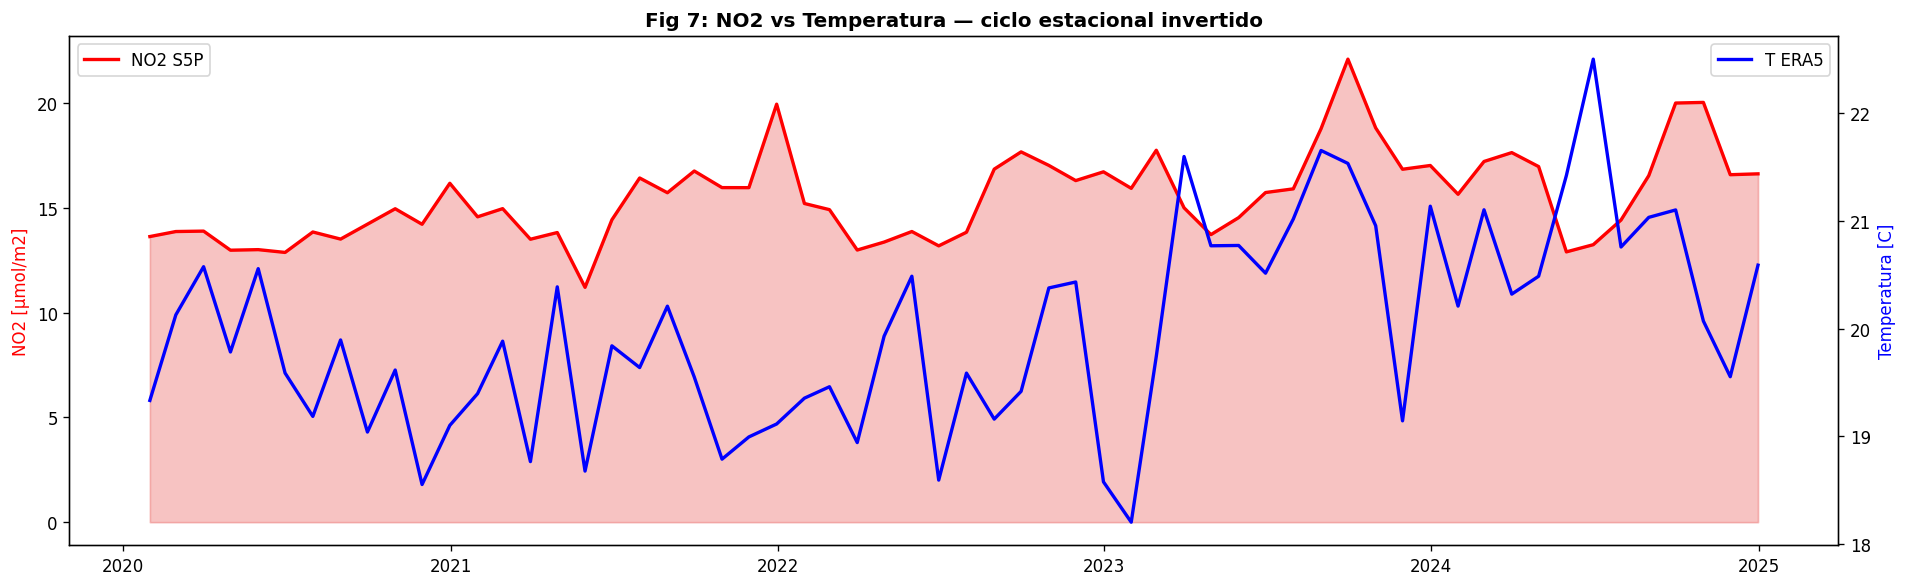

In [13]:
common_t = sorted(set(d.date() for d in no2_ts["date"]) & set(era5_temp.keys()))

if len(common_t) > 30:
    temp_ts = pd.DataFrame({"date": list(era5_temp.keys()), "temp": list(era5_temp.values())})
    temp_ts["date"] = pd.to_datetime(temp_ts["date"])
    temp_ts = temp_ts.set_index("date").sort_index()

    no2_monthly  = no2_ts.set_index("date").resample("ME").mean()
    temp_monthly = temp_ts.resample("ME").mean()
    common_idx   = no2_monthly.index.intersection(temp_monthly.index)

    if len(common_idx) > 5:
        fig, ax1 = plt.subplots(figsize=(16, 5))
        ax2 = ax1.twinx()
        ax1.fill_between(common_idx, no2_monthly.loc[common_idx]["no2"].values,
                         alpha=0.3, color="#E53935")
        ax1.plot(common_idx, no2_monthly.loc[common_idx]["no2"].values,
                 "r-", lw=2, label="NO2 S5P")
        ax2.plot(common_idx, temp_monthly.loc[common_idx]["temp"].values,
                 "b-", lw=2, label="T ERA5")
        ax1.set_ylabel("NO2 [µmol/m2]", color="red")
        ax2.set_ylabel("Temperatura [C]",  color="blue")
        ax1.legend(loc="upper left")
        ax2.legend(loc="upper right")
        ax1.set_title("Fig 7: NO2 vs Temperatura — ciclo estacional invertido", fontweight="bold")

        plt.tight_layout()
        plt.savefig(OUT_DIR / "07_no2_vs_temp_dual.png", dpi=DPI, bbox_inches="tight", facecolor="white")
        plt.show()
    else:
        print(f"  Índices comunes insuficientes: {len(common_idx)}")
else:
    print(f"  Datos insuficientes: {len(common_t)} fechas comunes")


## Fig 8 · S2 vs S5P — cobertura temporal mensual

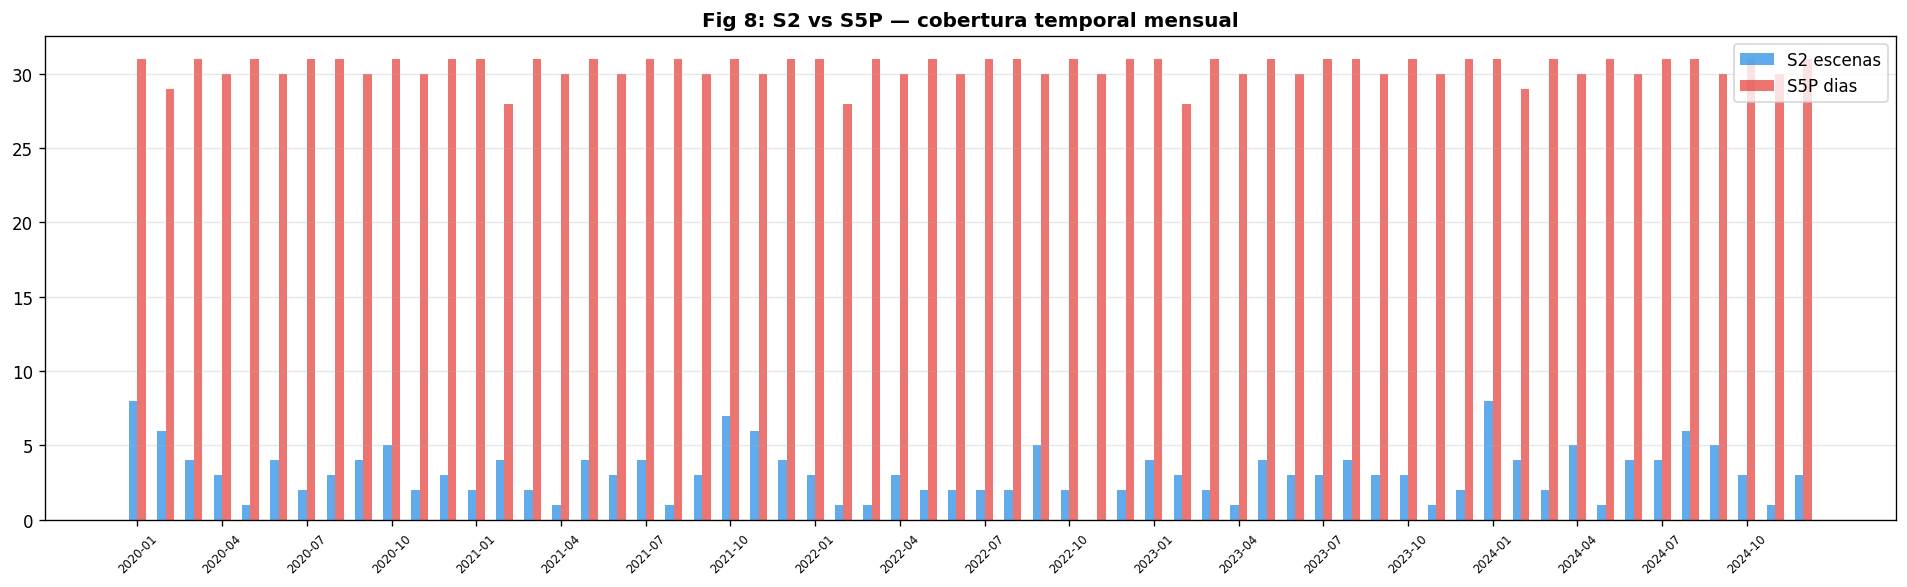

In [14]:
s2_monthly  = defaultdict(int)
for d in s2_dates:  s2_monthly[(d.year, d.month)]  += 1
s5p_monthly = defaultdict(int)
for d in s5p_dates: s5p_monthly[(d.year, d.month)] += 1

months = sorted(set(s2_monthly.keys()) | set(s5p_monthly.keys()))

fig, ax = plt.subplots(figsize=(16, 5))
ax.bar(np.arange(len(months)) - 0.15, [s2_monthly.get(m, 0)  for m in months],
       0.3, label="S2 escenas", color="#1E88E5", alpha=0.7)
ax.bar(np.arange(len(months)) + 0.15, [s5p_monthly.get(m, 0) for m in months],
       0.3, label="S5P dias",   color="#E53935", alpha=0.7)
ax.set_xticks(range(0, len(months), 3))
ax.set_xticklabels([f"{y}-{m:02d}" for y, m in months][::3], rotation=45, fontsize=7)
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_title("Fig 8: S2 vs S5P — cobertura temporal mensual", fontweight="bold")

plt.tight_layout()
plt.savefig(OUT_DIR / "08_s2_vs_s5p_cobertura.png", dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()


## Fig 9 · Datasets activos por día (máx 5)

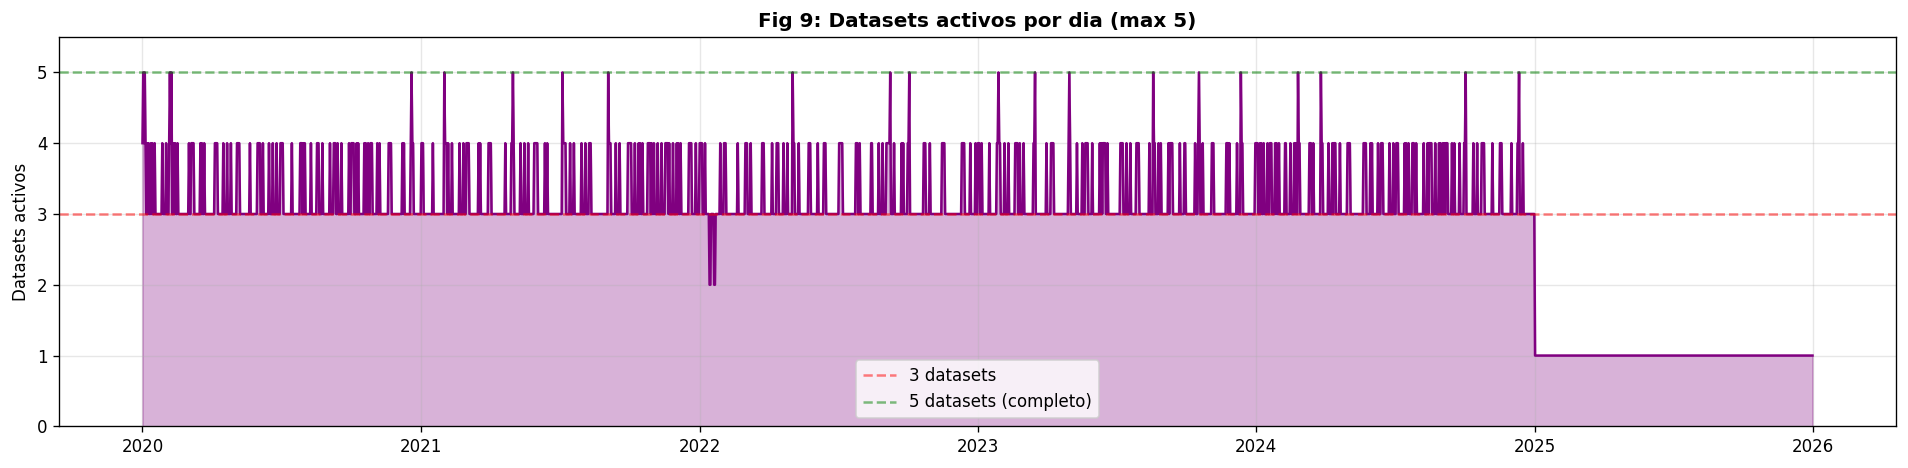

In [15]:
all_coverage = pd.DataFrame({
    "S5P":   [d in s5p_dates   for d in all_dates],
    "S2":    [d in s2_dates    for d in all_dates],
    "ERA5":  [d in era5_dates  for d in all_dates],
    "MODIS": [d in mod_dates   for d in all_dates],
    "DAGMA": [d in dagma_dates for d in all_dates],
}, index=all_dates)

daily_overlap = all_coverage.sum(axis=1)

fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(all_dates, daily_overlap.values, alpha=0.3, color="purple")
ax.plot(all_dates, daily_overlap.values, lw=1.5, color="purple")
ax.set_ylabel("Datasets activos")
ax.set_ylim(0, 5.5)
ax.axhline(3, color="red",   ls="--", alpha=0.5, label="3 datasets")
ax.axhline(5, color="green", ls="--", alpha=0.5, label="5 datasets (completo)")
ax.legend()
ax.set_title("Fig 9: Datasets activos por dia (max 5)", fontweight="bold")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "09_datasets_activos.png", dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()


## Fig 10 · Correlación cross-dataset (S5P + ERA5)

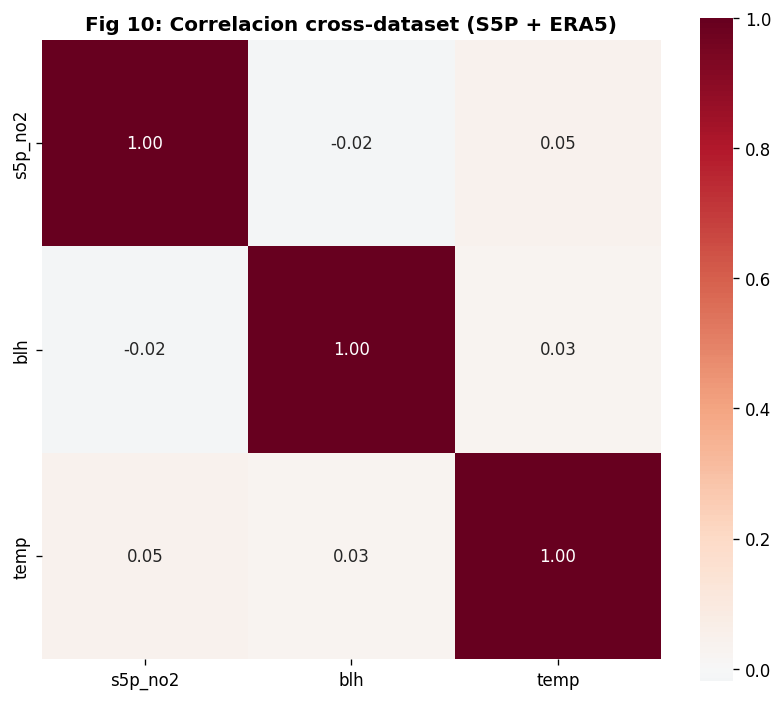

In [16]:
cross_data = {}
for dt in all_dates[:1000]:   # muestra
    if dt in s5p_dates and dt in era5_blh and dt in era5_temp:
        row_no2 = no2_ts[no2_ts["date"] == pd.Timestamp(dt)]
        cross_data[dt] = {
            "s5p_no2": row_no2["no2"].values[0] if len(row_no2) else np.nan,
            "blh":     era5_blh.get(dt, np.nan),
            "temp":    era5_temp.get(dt, np.nan),
        }

cross_df = pd.DataFrame(cross_data).T.dropna()

if len(cross_df) > 20:
    fig, ax = plt.subplots(figsize=(7, 6))
    corr = cross_df.corr()
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0, square=True, ax=ax)
    ax.set_title("Fig 10: Correlacion cross-dataset (S5P + ERA5)", fontweight="bold")

    plt.tight_layout()
    plt.savefig(OUT_DIR / "10_correlacion_cross.png", dpi=DPI, bbox_inches="tight", facecolor="white")
    plt.show()
else:
    print(f"  Datos insuficientes para correlacion: {len(cross_df)} filas válidas")


## Fig 11 · Dimensión del panel Big Data (>250 GB)

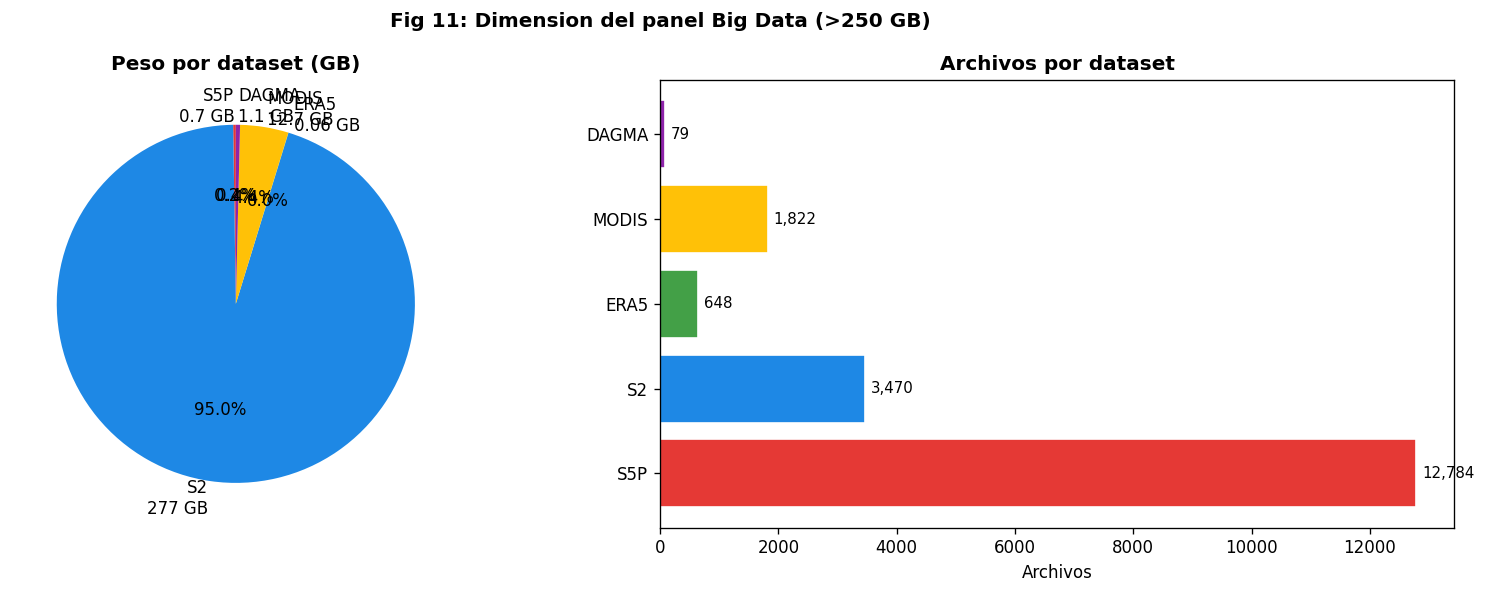

In [17]:
weights  = {"S5P": 0.7, "S2": 277, "ERA5": 0.06, "MODIS": 12.7, "DAGMA": 1.1}
archivos = {"S5P": 12784, "S2": 3470, "ERA5": 648,  "MODIS": 1822,  "DAGMA": 79}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.pie(weights.values(),
        labels=[f"{k}\n{v} GB" for k, v in weights.items()],
        autopct="%1.1f%%", colors=cols_pie, startangle=90)
ax1.set_title("Peso por dataset (GB)", fontweight="bold")

ax2.barh(list(archivos.keys()), archivos.values(), color=cols_pie, edgecolor="white")
for i, (k, v) in enumerate(archivos.items()):
    ax2.text(v + 100, i, f"{v:,}", va="center", fontsize=9)
ax2.set_xlabel("Archivos")
ax2.set_title("Archivos por dataset", fontweight="bold")

fig.suptitle("Fig 11: Dimension del panel Big Data (>250 GB)", fontweight="bold")
fig.tight_layout()
plt.savefig(OUT_DIR / "11_peso_panel.png", dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()


## Fig 12 · GB acumulados por dataset

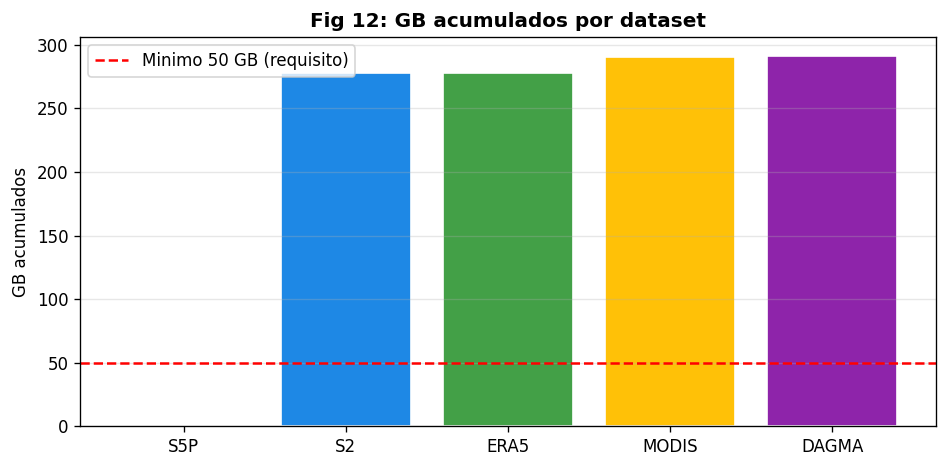

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))

gb_acum = [0.7, 277.7, 277.76, 290.46, 291.56]
ax.bar(["S5P", "S2", "ERA5", "MODIS", "DAGMA"], gb_acum, color=cols_pie, edgecolor="white")
ax.axhline(50, color="red", ls="--", lw=1.5, label="Minimo 50 GB (requisito)")
ax.set_ylabel("GB acumulados")
ax.legend()
ax.grid(axis="y", alpha=0.3)
ax.set_title("Fig 12: GB acumulados por dataset", fontweight="bold")

plt.tight_layout()
plt.savefig(OUT_DIR / "12_gb_acumulados.png", dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()


## Fig 13 · MODIS y S5P — cobertura temporal

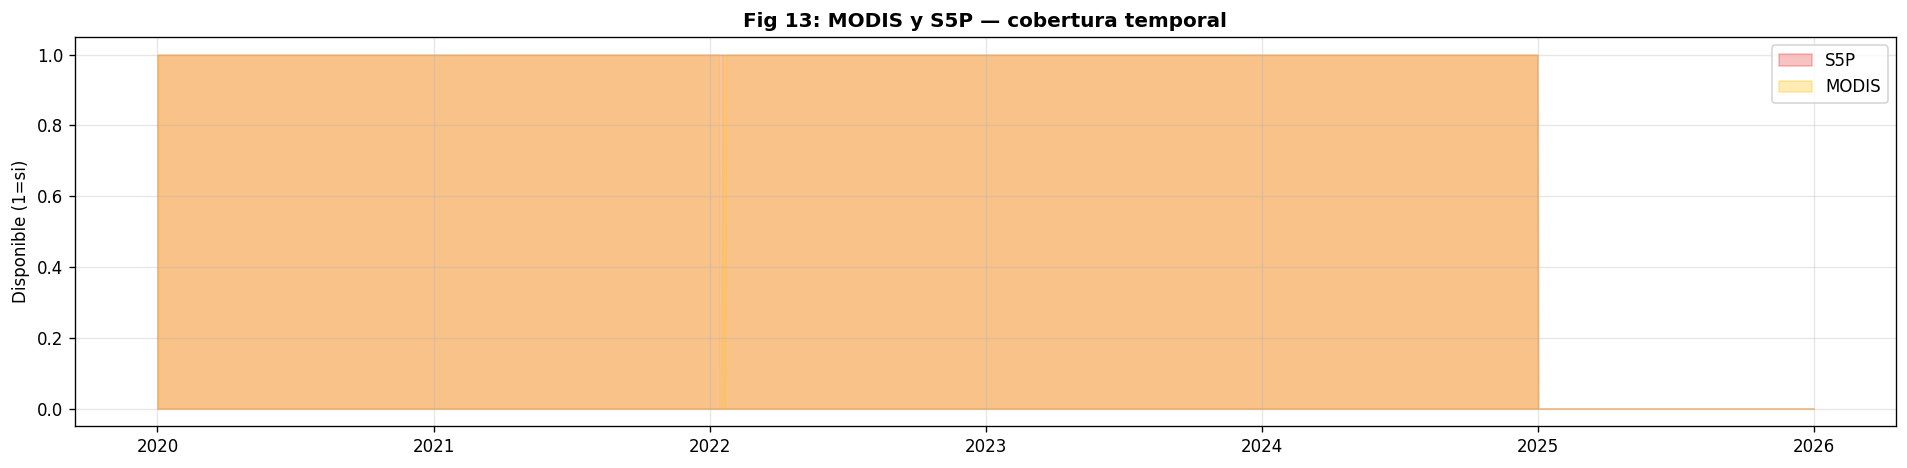

In [19]:
mod_all = pd.Series([d in mod_dates  for d in all_dates], index=all_dates)
s5p_all = pd.Series([d in s5p_dates for d in all_dates], index=all_dates)

fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(all_dates, s5p_all.astype(int), alpha=0.3, color="#E53935", label="S5P")
ax.fill_between(all_dates, mod_all.astype(int), alpha=0.3, color="#FFC107", label="MODIS")
ax.legend()
ax.set_ylabel("Disponible (1=si)")
ax.set_title("Fig 13: MODIS y S5P — cobertura temporal", fontweight="bold")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "13_modis_s5p_cobertura.png", dpi=DPI, bbox_inches="tight", facecolor="white")
plt.show()


## Resumen final

In [20]:
pngs = sorted(OUT_DIR.glob("*.png"))
print("=" * 60)
print("EDA Panel Completo — Integracion 5 datasets")
print("=" * 60)
print(f"  Output : {OUT_DIR}")
print(f"  Graficas generadas : {len(pngs)}")
print(f"  Datasets integrados: S5P + S2 + ERA5 + MODIS + DAGMA")
print(f"  Total datos referenciados: >250 GB")
print()
for p in pngs:
    print(f"  · {p.name}")


EDA Panel Completo — Integracion 5 datasets
  Output : /home/nicolas/Escritorio/Academico/analitica_datos/carlos_andres_ferro/geovision-clip-airquality/outputs/eda/panel
  Graficas generadas : 12
  Datasets integrados: S5P + S2 + ERA5 + MODIS + DAGMA
  Total datos referenciados: >250 GB

  · 01_cobertura_datasets.png
  · 02_heatmap_disponibilidad.png
  · 03_no2_vs_blh.png
  · 04_o3_vs_temperatura.png
  · 06_no2_s5p_vs_dagma.png
  · 07_no2_vs_temp_dual.png
  · 08_s2_vs_s5p_cobertura.png
  · 09_datasets_activos.png
  · 10_correlacion_cross.png
  · 11_peso_panel.png
  · 12_gb_acumulados.png
  · 13_modis_s5p_cobertura.png
